# Confronto tra Insertion Sort e Quick Sort

## Obiettivo

L'obiettivo di questo notebook è confrontare sperimentalmente due algoritmi
di ordinamento:

- Insertion Sort
- Quick Sort

Il confronto viene effettuato misurando:

- il tempo di esecuzione degli algoritmi;
- l'andamento delle prestazioni al crescere della dimensione dell'input;
- il comportamento su differenti tipologie di dati.

Vengono considerati tre scenari:

1. Dataset casuale;
2. Dataset già ordinato;
3. Dataset ordinato in modo decrescente.

In [9]:
import random
import time
import matplotlib.pyplot as plt

## Implementazione degli algoritmi

In questa sezione vengono implementati i due algoritmi di ordinamento.

### Insertion Sort

Insertion Sort costruisce progressivamente una sequenza ordinata,
inserendo ogni elemento nella posizione corretta rispetto agli elementi
precedenti.

Complessità:

- caso migliore: O(n)
- caso medio: O(n²)
- caso peggiore: O(n²)


### Quick Sort

Quick Sort utilizza la tecnica divide et impera.
L'algoritmo seleziona un elemento pivot e divide il vettore in due parti:
gli elementi minori del pivot e quelli maggiori.

In questa implementazione viene utilizzato un pivot casuale per evitare
situazioni particolarmente sfavorevoli.

Complessità:

- caso migliore: O(n log n)
- caso medio: O(n log n)
- caso peggiore: O(n²)

In [10]:
def insertion_sort(A):
    A = A.copy()

    for i in range(1, len(A)):
        key = A[i]
        j = i - 1

        while j >= 0 and A[j] > key:
            A[j + 1] = A[j]
            j -= 1

        A[j + 1] = key

    return A



def quick_sort(A):
    A = A.copy()

    def quick(low, high):
        if low < high:
            p = partition(low, high)
            quick(low, p - 1)
            quick(p + 1, high)


    def partition(low, high):

        # scelta casuale del pivot
        pivot_index = random.randint(low, high)

        A[pivot_index], A[high] = A[high], A[pivot_index]

        pivot = A[high]

        i = low - 1

        for j in range(low, high):
            if A[j] <= pivot:
                i += 1
                A[i], A[j] = A[j], A[i]

        A[i + 1], A[high] = A[high], A[i + 1]

        return i + 1


    quick(0, len(A)-1)

    return A

## Generazione dei dataset

Per valutare il comportamento degli algoritmi vengono utilizzate tre
tipologie di input:

- Dataset casuale: elementi generati casualmente;
- Dataset ordinato: elementi già ordinati in senso crescente;
- Dataset inverso: elementi ordinati in senso decrescente.

Le dimensioni degli input considerate sono:

100, 500, 1000, 5000, 10000 e 20000 elementi.

In [11]:
def random_dataset(n):
    return random.sample(range(n * 10), n)



def sorted_dataset(n):
    return list(range(n))



def reversed_dataset(n):
    return list(range(n, 0, -1))

## Funzione di benchmark

Per confrontare le prestazioni viene misurato il tempo necessario
all'esecuzione di ciascun algoritmo tramite la funzione
`time.perf_counter()`.

In [12]:
def benchmark(algorithm, data):

    start = time.perf_counter()

    algorithm(data)

    end = time.perf_counter()

    return end - start

## Test su dataset casuale

Vengono confrontati i tempi di esecuzione dei due algoritmi su input
generati casualmente.

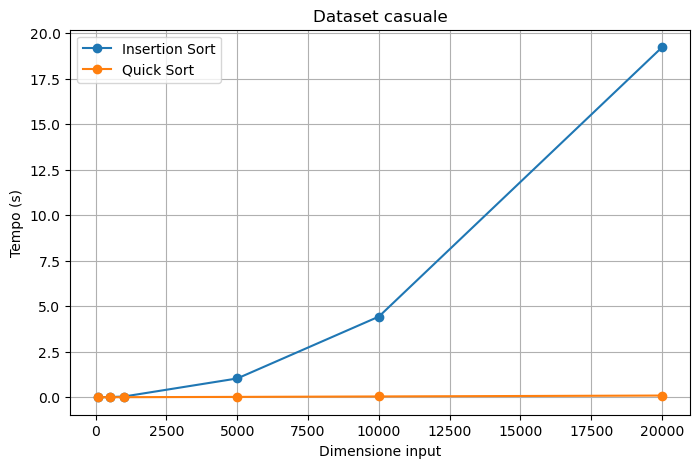

In [13]:
sizes = [
    100,
    500,
    1000,
    5000,
    10000,
    20000
]


times_insertion = []
times_quick = []


for n in sizes:

    data = random_dataset(n)

    times_insertion.append(
        benchmark(insertion_sort, data)
    )

    times_quick.append(
        benchmark(quick_sort, data)
    )



plt.figure(figsize=(8,5))

plt.plot(
    sizes,
    times_insertion,
    marker="o",
    label="Insertion Sort"
)

plt.plot(
    sizes,
    times_quick,
    marker="o",
    label="Quick Sort"
)


plt.xlabel("Dimensione input")
plt.ylabel("Tempo (s)")
plt.title("Dataset casuale")

plt.grid(True)
plt.legend()

plt.show()

## Test su dataset ordinato

Viene analizzato il comportamento degli algoritmi quando l'input è già
ordinato in senso crescente.

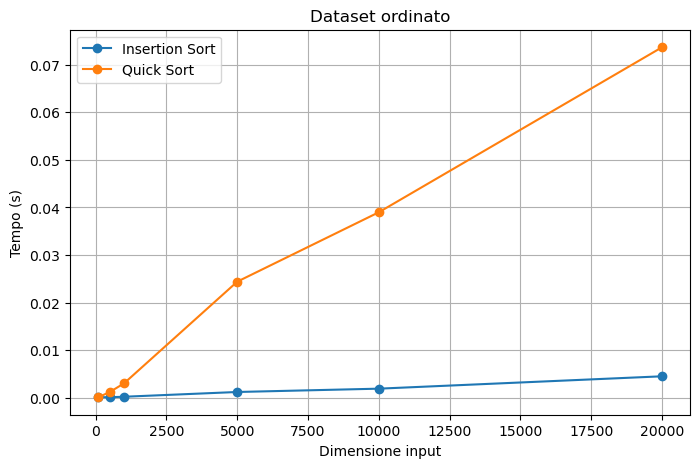

In [14]:
times_insertion_sorted = []
times_quick_sorted = []


for n in sizes:

    data = sorted_dataset(n)

    times_insertion_sorted.append(
        benchmark(insertion_sort, data)
    )

    times_quick_sorted.append(
        benchmark(quick_sort, data)
    )



plt.figure(figsize=(8,5))


plt.plot(
    sizes,
    times_insertion_sorted,
    marker="o",
    label="Insertion Sort"
)

plt.plot(
    sizes,
    times_quick_sorted,
    marker="o",
    label="Quick Sort"
)


plt.xlabel("Dimensione input")
plt.ylabel("Tempo (s)")
plt.title("Dataset ordinato")

plt.grid(True)
plt.legend()

plt.show()

## Test su dataset inverso

Viene analizzato il caso in cui gli elementi sono ordinati in senso
decrescente, situazione sfavorevole per Insertion Sort.

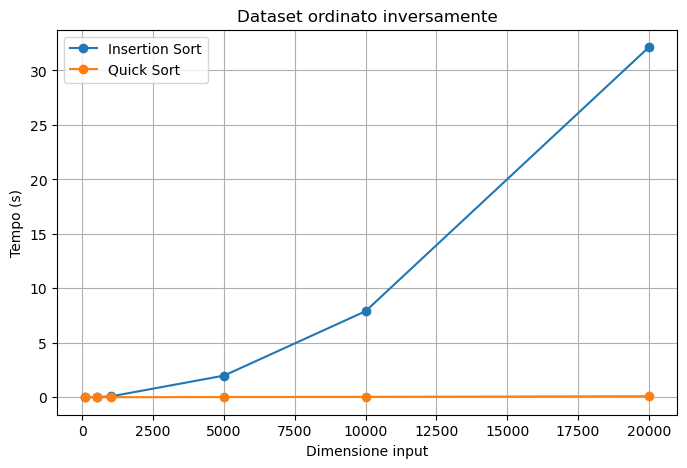

In [15]:
times_insertion_reverse = []
times_quick_reverse = []


for n in sizes:

    data = reversed_dataset(n)

    times_insertion_reverse.append(
        benchmark(insertion_sort, data)
    )

    times_quick_reverse.append(
        benchmark(quick_sort, data)
    )



plt.figure(figsize=(8,5))


plt.plot(
    sizes,
    times_insertion_reverse,
    marker="o",
    label="Insertion Sort"
)

plt.plot(
    sizes,
    times_quick_reverse,
    marker="o",
    label="Quick Sort"
)


plt.xlabel("Dimensione input")
plt.ylabel("Tempo (s)")
plt.title("Dataset ordinato inversamente")

plt.grid(True)
plt.legend()

plt.show()

# Conclusioni

Dai risultati sperimentali ottenuti si osserva che:

- Insertion Sort presenta una crescita quadratica e diventa rapidamente
  inefficiente all'aumentare della dimensione dell'input.

- Quick Sort risulta generalmente più veloce grazie alla complessità media
  O(n log n).

- Nei dataset casuali Quick Sort mostra prestazioni nettamente superiori
  rispetto a Insertion Sort.

- Nel caso di dataset già ordinati, Insertion Sort raggiunge il caso migliore
  O(n), mentre Quick Sort mantiene buone prestazioni grazie alla scelta
  casuale del pivot.

- La scelta del pivot è un elemento fondamentale per evitare il caso peggiore
  di Quick Sort.